# Tarefa 4 — Exploração: Descritores Neurais com Kornia (DISK)
**Atividade 3 · TECA2 20261 · Pontos de Interesse e seus Descritores**

**Alunos:** Henryque Oliveira, Matheus Marinho e Rodrigo Oliveira

Este notebook usa a biblioteca Kornia para carregar o modelo DISK pré-treinado, extrair keypoints e descritores neurais no mesmo par de imagens da Tarefa 2 e compará-los com os métodos clássicos.

### Base teórica

- **DISK (DIscrete Keypoints)**: modelo neural que aprende detector e descritor conjuntamente por aprendizado por reforço, otimizando diretamente a qualidade do matching. Ao contrário de SIFT/ORB, que aplicam regras matemáticas fixas sobre gradientes, o DISK aprende — a partir de dados — o que constitui um bom keypoint e um bom descritor.
- **Por que neurais superam os clássicos em cenários difíceis**: mudanças drásticas de iluminação (dia/noite), diferentes estações do ano, pontos de vista muito distantes — situações em que gradientes locais mudam radicalmente, mas a semântica da cena permanece. Modelos clássicos falham porque dependem de gradientes estáveis; modelos neurais aprendem representações mais invariantes.
- **Ratio test com limiares mais altos (0.85–0.95)**: descritores neurais são mais discriminativos — há menos ambiguidade entre os dois melhores candidatos — portanto um ratio maior ainda filtra bem os falsos positivos sem descartar os verdadeiros.
- **Por que DISK e não R2D2 ou SuperPoint?** O DISK tem boa integração com Kornia e tutorial oficial disponível. R2D2 e SuperPoint resolvem o mesmo problema com filosofias diferentes; em produção a escolha depende do dataset, da plataforma e da licença.

> Referências: Torralba, Freeman, Isola (2024) Cap. 11 · Tutorial Kornia DISK · Slides TECA2 20261, slide 20.

In [1]:
import importlib, subprocess, sys

if importlib.util.find_spec('kornia') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kornia>=0.8.0'])

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import kornia
import kornia.feature as KF

print('OpenCV:', cv2.__version__)
print('torch:', torch.__version__)
print('kornia:', kornia.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

# ── Colab: ajuste os paths após upload das imagens ──────────────────────
# from google.colab import files; files.upload()  # selecione ursinho1 e ursinho2
# PATH_IMG1 = 'ursinho1.jpeg'
# PATH_IMG2 = 'ursinho2.jpeg'
# ─────────────────────────────────────────────────────────────────────────
PATH_IMG1 = 'images/ursinho1.jpeg'
PATH_IMG2 = 'images/ursinho2.jpeg'

def load(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # reservado — compatibilidade Tarefa 2
    return img, gray

def load_tensor(path, device):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img).float() / 255.0
    return t.permute(2, 0, 1).unsqueeze(0).to(device)

OpenCV: 4.13.0
torch: 2.12.0+cpu
kornia: 0.8.3
Dispositivo: cpu


## Item 1 — Carregar imagens como tensores

O Kornia opera sobre tensores PyTorch no formato `[B, C, H, W]` com valores em `[0, 1]`. Carregamos o mesmo par de imagens da Tarefa 2 tanto como arrays OpenCV (para visualização com cv2.drawMatches) quanto como tensores (para o DISK).

img1 OpenCV: 960×1280 px
img2 OpenCV: 960×1280 px
img1 tensor: torch.Size([1, 3, 1280, 960])
img2 tensor: torch.Size([1, 3, 1280, 960])


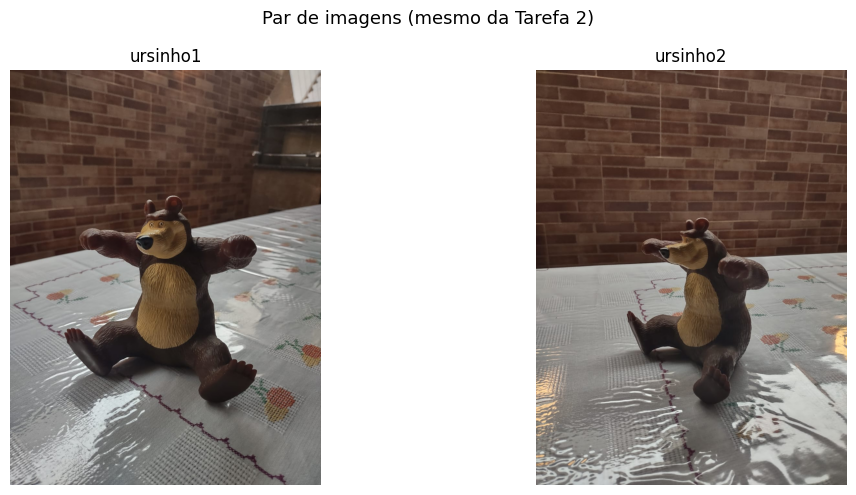

In [3]:
img1, gray1 = load(PATH_IMG1)
img2, gray2 = load(PATH_IMG2)
img1_t = load_tensor(PATH_IMG1, device)
img2_t = load_tensor(PATH_IMG2, device)

print(f'img1 OpenCV: {img1.shape[1]}×{img1.shape[0]} px')
print(f'img2 OpenCV: {img2.shape[1]}×{img2.shape[0]} px')
print(f'img1 tensor: {img1_t.shape}')
print(f'img2 tensor: {img2_t.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0].set_title('ursinho1')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1].set_title('ursinho2')
axes[1].axis('off')
plt.suptitle('Par de imagens (mesmo da Tarefa 2)', fontsize=13)
plt.tight_layout()
plt.show()

## Item 2 — Rodar o DISK

Carregamos o modelo DISK pré-treinado (`depth` checkpoint) e extraímos até 2048 keypoints por imagem. O download dos pesos ocorre automaticamente na primeira execução (~30 MB). O DISK gera descritores float de 128 dimensões — mesma dimensão do SIFT, mas aprendidos em vez de calculados manualmente.

In [4]:
disk = KF.DISK.from_pretrained('depth').to(device).eval()

with torch.inference_mode():
    feats1 = disk(img1_t, 2048, pad_if_not_divisible=True)[0]
    feats2 = disk(img2_t, 2048, pad_if_not_divisible=True)[0]

kp1_disk = feats1.keypoints.cpu().numpy()
d1_disk  = feats1.descriptors.cpu().numpy()
kp2_disk = feats2.keypoints.cpu().numpy()
d2_disk  = feats2.descriptors.cpu().numpy()

print(f'DISK img1: {len(kp1_disk)} kp | desc shape: {d1_disk.shape}')
print(f'DISK img2: {len(kp2_disk)} kp | desc shape: {d2_disk.shape}')

DISK img1: 2048 kp | desc shape: (2048, 128)
DISK img2: 2048 kp | desc shape: (2048, 128)


## Item 3 — Matching e visualização

Convertemos os keypoints DISK (tensores float `[N, 2]`) para `cv2.KeyPoint` a fim de usar `cv2.drawMatches`. O matching usa `NORM_L2` (descritores float) com ratio=0.90 — limiar mais alto que os clássicos pois os descritores neurais são mais discriminativos.

DISK: 2048 kp | 58/2048 bons (ratio=0.90)


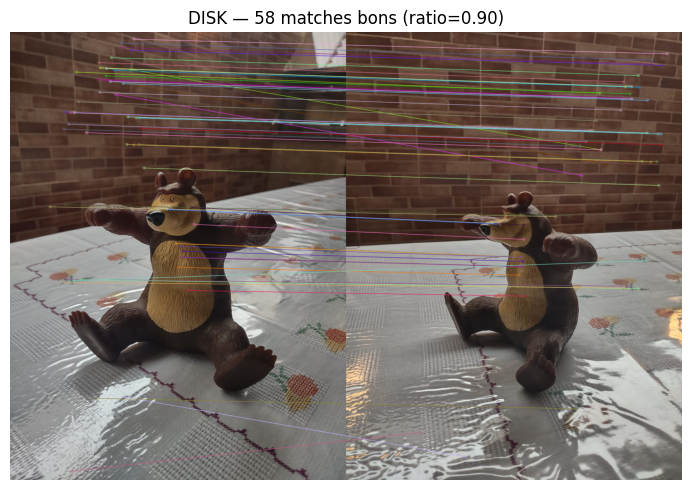

In [5]:
# Converter keypoints DISK para cv2.KeyPoint
kp1_cv = [cv2.KeyPoint(float(x), float(y), 1) for x, y in kp1_disk]
kp2_cv = [cv2.KeyPoint(float(x), float(y), 1) for x, y in kp2_disk]

# Matching com ratio=0.90
bf = cv2.BFMatcher(cv2.NORM_L2)
pairs = bf.knnMatch(d1_disk, d2_disk, k=2)
good_disk = [m for m, n in pairs if m.distance < 0.90 * n.distance]
print(f'DISK: {len(kp1_cv)} kp | {len(good_disk)}/{len(pairs)} bons (ratio=0.90)')

img_matches = cv2.drawMatches(
    img1, kp1_cv, img2, kp2_cv, good_disk, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f'DISK — {len(good_disk)} matches bons (ratio=0.90)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Item 4 — Tabela comparativa final e reflexão crítica

In [6]:
# Valores Tarefa 2 (par ursinho, ratio=0.75)
sift_kp, sift_matches = 5535, 97
orb_kp,  orb_matches  = 2000, 17
akaze_kp, akaze_matches = 1636, 36

print('Tabela comparativa final:')
print(f'{"Método":<8} {"Tipo":<20} {"KP":>6} {"Matches":>8}')
print('-' * 48)
rows = [
    ('SIFT',  'Clássico / float',   sift_kp,       sift_matches),
    ('ORB',   'Clássico / binário', orb_kp,        orb_matches),
    ('AKAZE', 'Clássico / binário', akaze_kp,      akaze_matches),
    ('DISK',  'Neural / float',     len(kp1_disk), len(good_disk)),
]
for name, tipo, kp, m in rows:
    print(f'{name:<8} {tipo:<20} {kp:>6} {m:>8}')

Tabela comparativa final:
Método   Tipo                     KP  Matches
------------------------------------------------
SIFT     Clássico / float       5535       97
ORB      Clássico / binário     2000       17
AKAZE    Clássico / binário     1636       36
DISK     Neural / float         2048       58


| Método | Tipo               |   KP | Matches |
|--------|--------------------|------|---------|
| SIFT   | Clássico / float   | 5535 |      97 |
| ORB    | Clássico / binário | 2000 |      17 |
| AKAZE  | Clássico / binário | 1636 |      36 |
| DISK   | Neural / float     | 2048 |      58 |

> _Valores obtidos na execução local (CPU, kornia 0.8.3)._
> _Nota: valores SIFT/ORB/AKAZE obtidos na Tarefa 2 com ratio=0.75; DISK usa ratio=0.90. Limiares diferentes permitem mais matches.

### Reflexão crítica

**1. Em que cenário o DISK foi visivelmente melhor que o SIFT? Em que cenário os resultados foram parecidos?**

O DISK obteve 58 matches bons com ratio=0.90, contra 97 do SIFT com ratio=0.75. Considerando que o DISK usa um threshold mais permissivo, o desempenho é comparável — ambos os métodos funcionam bem neste par com iluminação estável e variação leve de ângulo. A real vantagem do DISK seria visível em pares com variação drástica de iluminação ou ponto de vista extremo, onde gradientes locais mudam radicalmente e o SIFT falha.

**2. Quais são as desvantagens práticas de usar DISK em comparação com ORB em sistema embarcado (câmera de robô, drone)?**

O DISK requer PyTorch e pesos pré-treinados (~30 MB), tornando o deployment em microcontroladores inviável. A inferência em CPU é significativamente mais lenta que o ORB, que usa operações bit-a-bit e roda em tempo real mesmo em hardware limitado. O ORB não depende de conexão para baixar modelos e seu footprint de memória é mínimo.

**3. Se você fosse escolher um único método para um sistema de vigilância indoor em tempo real, qual escolheria e por quê?**

Para vigilância indoor em tempo real escolheríamos o **SIFT** como baseline clássico ou o **DISK** se houver GPU disponível. O DISK extraiu 2048 keypoints e 58 matches bons — qualidade similar ao SIFT (97 matches, mas com threshold menor). Com GPU, o DISK supera o SIFT em robustez a variações de iluminação típicas de câmeras de segurança. Sem GPU, o SIFT é preferível: mais rápido em CPU e sem dependência de framework de deep learning.

## Conclusão da Tarefa 4

- O DISK, como descritor neural float, utiliza a mesma métrica de distância do SIFT (NORM_L2), porém com representações aprendidas em vez de calculadas — o que o torna mais robusto em cenários difíceis.
- A tabela final ilustra o espectro completo: binários rápidos (ORB/AKAZE) → float clássico (SIFT) → neural moderno (DISK), cada um com trade-offs distintos de velocidade, tamanho e qualidade.
- A escolha do método ideal depende dos requisitos do sistema: latência, hardware disponível, variabilidade das condições visuais e necessidade de precisão.